# Gated Recurrent Unit (GRU)

## 1. Why GRUs?  
- **RNN Limitation:** Struggles with long sequences due to *vanishing/exploding gradient problem*.  
- **LSTM Solution:** Introduced long-term and short-term memory using separate cell state and hidden state, with 3 gates (Forget, Input, Output).  
- **But Problem with LSTMs:**  
  - Complex architecture → more parameters.  
  - More parameters → longer training time (especially on large datasets).  

## 2. GRU Introduction  
- Proposed in **2014** (later than LSTM, ~1997).  
- Simplified architecture compared to LSTM.  
- **Only two gates:** Reset Gate and Update Gate.  
- **Single State:** GRUs do not maintain a separate cell state → hidden state alone carries both short-term and long-term context.  
- Fewer parameters → **faster training**.  
- Performance is **comparable to LSTMs**. On some datasets, GRUs outperform LSTMs, though not always.  

## 3. Big Idea Behind GRU  
- Instead of maintaining **two states** (cell state + hidden state) like LSTM, GRU uses **only hidden state**.  
- Reset Gate and Update Gate control how much of past information is forgotten or updated at each time step.  
- Provides balance of **simplicity + effectiveness**.  

## 4. GRU vs LSTM (High-level)  
| Feature               | LSTM                                | GRU                            |
|------------------------|-------------------------------------|--------------------------------|
| Gates                  | 3 (Forget, Input, Output)           | 2 (Reset, Update)              |
| States                 | 2 (Cell state, Hidden state)        | 1 (Hidden state only)          |
| Parameters             | Higher (slower training)            | Fewer (faster training)        |
| Complexity             | More complex                       | Simpler                        |
| Performance            | Strong in many NLP/sequence tasks   | Comparable; sometimes better   |

---


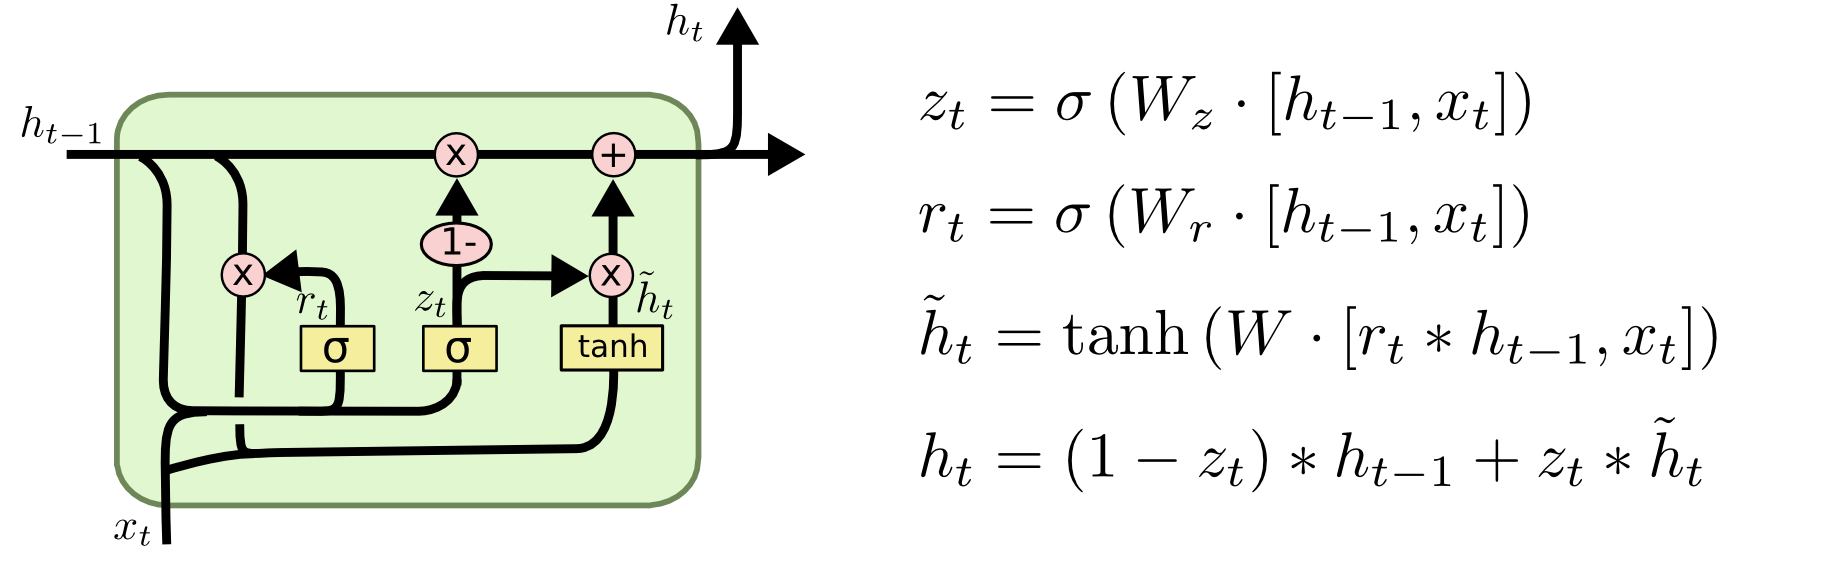

# GRU Setup and Preliminaries

Before diving into the **architecture of GRUs (Gated Recurrent Units)**, it is important to understand the setup and components.  

---

## Key Advice
- If you have already studied **LSTM**, GRUs will not feel very difficult.  
- However, GRUs can be **confusing**: you may think you understood them, but explaining or implementing might reveal gaps.  
- Be careful while learning; clarity on every step is important.  

---

## Goal of GRU
- For any time step *t*, the GRU receives:
  - **Previous hidden state:** $( h_{t-1} $)  
  - **Current input:** $( x_t $)  
- Using these, the GRU computes the **current hidden state** $( h_t $).  
- The hidden state captures both short-term and long-term context.  
- To achieve this, GRUs use **two gates: reset gate (r\_t)** and **update gate (z\_t)**.

---

## Important Symbols
- $( h_{t-1} $): Previous hidden state  
- $( h_t $): Current hidden state  
- $( x_t $): Input at time step *t*  
- $( r_t $): Reset gate  
- $( z_t $): Update gate  
- $( \tilde{h}_t $): Candidate hidden state  

👉 All of these (except $( x_t $)) are **vectors** with the same dimensionality.  
👉 The dimensionality depends on the **number of hidden units** chosen as a hyperparameter.  

---

## Components in GRU Diagram
1. **Vectors**  
   - $( h_{t-1}, h_t, r_t, z_t, \tilde{h}_t $) → all vectors of equal dimension.  
   - Only $( x_t $) can have a different dimension.

2. **Neural Network Layers (Yellow Boxes)**  
   - Represent **fully connected layers** with activation functions.  
   - Typically use **sigmoid (σ)** or **tanh (tanh)** activations.  
   - The number of units in these layers = number of hidden units chosen.  
   - All gates must have the **same number of units**.  

3. **Element-wise Operations (Pink Circles)**  
   - ⊙ → Element-wise multiplication  
   - + → Element-wise addition  
   - (1 - z) → Element-wise subtraction  
   - Example:  
     - If $( h_{t-1} = [a, b, c] $) and $( r_t = [d, e, f] $), then  
       $( h_{t-1} ⊙ r_t = [ad, be, cf] $).  

---

## Summary of Setup
- GRUs operate with **vectors, neural network layers, and element-wise operations**.  
- Once you understand these components, you are fully prepared to study how:  
  - Reset gate works  
  - Update gate works  
  - Final hidden state $( h_t $) is computed  


# Why $(x_t$) (Input) is a Vector in GRU

Before studying the GRU architecture, we must clarify why the input at each time step, $(x_t$), is represented as a **vector**.

---

## Motivation
- GRUs (and RNNs in general) cannot directly understand **words**.  
- Hence, words or sentences must be converted into **numerical vectors** (vectorization).  

---

## Example: Sentiment Analysis
Suppose we have three sample text reviews:

1. **Sentence 1:** "cat mat rat"  
2. **Sentence 2:** "cat rat rat"  
3. **Sentence 3:** "mat rat mat"  

### Step 1: Identify Unique Words
- Vocabulary = {cat, mat, rat}  
- Total unique words = 3  

### Step 2: Represent Words as Vectors  
Using **One-Hot Encoding (OHE):**  
- cat → [1, 0, 0]  
- mat → [0, 1, 0]  
- rat → [0, 0, 1]  

### Step 3: Convert Sentences
- Sentence 1 → [ [1,0,0], [0,1,0], [0,0,1] ]  
- Sentence 2 → [ [1,0,0], [0,0,1], [0,0,1] ]  
- Sentence 3 → [ [0,1,0], [0,0,1], [0,1,0] ]  

### Step 4: Sequential Input to GRU
- At **time step 1** → $( x_t = $) first word’s vector  
- At **time step 2** → $( x_t = $) second word’s vector  
- At **time step 3** → $( x_t = $) third word’s vector  

Thus, GRU processes **one word vector per time step**.

---

## Generalization
- $(x_t$) can come from different vectorization techniques:  
  - **Basic:** One-Hot Encoding, Bag of Words  
  - **Advanced:** Word2Vec, embeddings from neural networks  
- Regardless of method, the **final input to GRU is always a vector**.

---

## Conclusion
- $(x_t$) is always a **vector representation of the input at time t**.  
- Now that setup is complete, we are ready to explore the **GRU architecture in detail** (Reset Gate, Update Gate, Candidate Hidden State).


# GRU: Stepwise Computation Workflow

The main goal of a GRU (Gated Recurrent Unit) is:  
**Given two inputs at time step t → $(h_{t-1}$) (previous hidden state) and $(x_t$) (current input), compute $(h_t$) (current hidden state).**

---

## Flow of Information
The entire process is divided into **4 sequential steps**:

### **Step 1: Compute Reset Gate ($(r_t$))**
- Determines how much of the **previous hidden state** ($(h_{t-1}$)) should be ignored or “reset” before creating the candidate hidden state.  

---

### **Step 2: Compute Candidate Hidden State ($(\tilde{h}_t$))**
- A temporary hidden state generated using:
  - Current input $(x_t$)  
  - Previous hidden state $(h_{t-1}$), filtered by the Reset Gate ($(r_t$))  
- Represents a potential new memory.

---

### **Step 3: Compute Update Gate ($(z_t$))**
- Controls how much of:
  - The **old memory** ($(h_{t-1}$))  
  - The **new candidate memory** ($(\tilde{h}_t$))  
  should be combined to form the final hidden state.

---

### **Step 4: Compute Final Hidden State (\(h_t\))**
- The actual hidden state at time $(t$).  
- Obtained by a weighted combination of:
  - Previous hidden state ($(h_{t-1}$))  
  - Candidate hidden state ($(\tilde{h}_t$))  
- The weights are decided by the Update Gate ($(z_t$)).

---

## Intuitive Flow Diagram (Conceptual)

1. Start with $(h_{t-1}$) and $(x_t$).  
2. Use them to calculate **Reset Gate ($(r_t$))** → controls memory reset.  
3. Combine $(h_{t-1}$), $(x_t$), and $(r_t$) → compute **Candidate Hidden State ($(\tilde{h}_t$))**.  
4. Calculate **Update Gate ($(z_t$))** → decides mix ratio.  
5. Final hidden state:  
   $$
   h_t = z_t \cdot h_{t-1} + (1 - z_t) \cdot \tilde{h}_t
   $$

---

## Summary
- GRU works like a **controlled memory unit**.  
- Reset Gate decides *how much past to forget*.  
- Candidate Hidden State proposes *a possible new memory*.  
- Update Gate decides *how much of old vs new memory to keep*.  
- Final Hidden State $(h_t$) = dynamic blend of past + present.


# GRU: Hidden State Intuition and Architecture

## Hidden State Intuition
- The main goal of GRU is: at each time step *t*, it receives the **previous hidden state** (*h<sub>t-1</sub>*) and the **current input** (*x<sub>t</sub>*), and produces the **new hidden state** (*h<sub>t</sub>*).  
- Intuitively, the hidden state can be seen as the **memory** of the system.  
- As words/sentences are processed step by step, GRU (like LSTM) maintains a memory of the **context** so that the model understands "what has happened so far" in the sequence.

### Story Analogy
- Example story: King Vikram, his enemy Kali, battles, deaths, and revenge.  
- The hidden state vector can be thought of as numbers tracking different **aspects** of the story:
  - Power
  - Conflict
  - Tragedy
  - Revenge
- At each time step, as new sentences are introduced, the hidden state updates these aspects.  
  - E.g., introduction of a king → power ↑  
  - Death → tragedy ↑  
  - Mention of revenge → revenge ↑  
- Thus, hidden states evolve as a **summary of the story so far**.

### Key Idea
- Hidden state is a **vector of numbers** that represents context.  
- Individually, numbers may not be interpretable, but collectively they encode the overall memory.  
- GRU modifies these numbers step by step, balancing **past memory** and **current input**.

---

## Two-Step Transition Process
To move from *h<sub>t-1</sub>* → *h<sub>t</sub>*, GRU works in two stages:

1. **Candidate Memory Formation**
   - Using *h<sub>t-1</sub>* (previous memory) + *x<sub>t</sub>* (current input), GRU forms a **candidate hidden state** (*h̃<sub>t</sub>*).
   - This represents the potential new memory if the current input were given full importance.

2. **Balancing and Updating**
   - GRU does not directly accept *h̃<sub>t</sub>* as final memory.  
   - Instead, it balances *h<sub>t-1</sub>* and *h̃<sub>t</sub>* using **gates**, producing the final *h<sub>t</sub>*.
   - This balance depends on how important the new input is relative to past memory.

---

## GRU Gates
Two gates control memory flow:

1. **Reset Gate (r<sub>t</sub>)**
   - Controls **how much of past memory** (*h<sub>t-1</sub>*) should influence the candidate memory.  
   - Helps decide whether to forget irrelevant parts of the past.

2. **Update Gate (z<sub>t</sub>)**
   - Balances between **past memory** (*h<sub>t-1</sub>*) and **candidate memory** (*h̃<sub>t</sub>*).  
   - Determines how much new information should be added and how much past should be retained.

---

## Mathematical Flow of GRU
1. Inputs: previous hidden state (*h<sub>t-1</sub>*) and current input (*x<sub>t</sub>*).  
2. Compute **reset gate**:  
   $$
   r_t = \sigma(W_r \cdot [h_{t-1}, x_t])
   $$
3. Form **reset hidden state**:  
   $$
   \tilde{h}' = r_t \odot h_{t-1}
   $$
4. Compute **candidate hidden state**:  
   $$
   \tilde{h}_t = \tanh(W \cdot [\tilde{h}', x_t])
   $$
5. Compute **update gate**:  
   $$
   z_t = \sigma(W_z \cdot [h_{t-1}, x_t])
   $$
6. Form **final hidden state**:  
   $$
   h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
   $$

---

## Intuition Recap
- *h<sub>t</sub>* acts as the **contextual memory** of the story so far.  
- Reset gate decides **which past information to keep/forget**.  
- Update gate decides **how much new information to add**.  
- Together, they allow GRU to capture dependencies across time while avoiding vanishing gradients.

---


# GRU — Step-by-step: Reset Gate → Candidate → Update → Final Hidden

## Goal (one line)
For each time step $t$ the GRU receives the **previous hidden state** $h_{t-1}$ and the **current input** $x_t$, and computes the **current hidden state** $h_t$ (the new memory / context).

---

## Notation & shapes
- $h_{t-1} \in \mathbb{R}^H$ — previous hidden state ($H$ = number of hidden units).  
- $x_t \in \mathbb{R}^D$ — current input vector ($D$ = input dim).  
- Concatenation: $[h_{t-1}; x_t] \in \mathbb{R}^{H+D}$.  
- Weight matrices & biases (typical shapes):  
  - $W_r, W_z, W_h \in \mathbb{R}^{H \times (H + D)}$  
  - $b_r, b_z, b_h \in \mathbb{R}^{H}$  
- Gate outputs: $r_t, z_t, \tilde{h}_t, h_t \in \mathbb{R}^H$.  

All element-wise operations ($\odot$, $+$, $1 - z_t$) are performed dimension-wise.

---

## Step 1 — Reset gate $r_t$
**Purpose:** decide which parts (dimensions) of the previous memory to *reset/ignore* before forming the candidate.  

**Formula:**
$$
r_t = \sigma\big(W_r\,[h_{t-1}; x_t] + b_r\big)
$$

**Properties & intuition**
- Each component of $r_t$ is in $(0,1)$.  
  - $r_{t,i} \approx 0$ → for that dimension, forget (reset) the past.  
  - $r_{t,i} \approx 1$ → keep the past information in that dimension.  
- Think of $r_t$ as a per-dimension “mask” controlled by the current input.

**Computation detail (shape/params)**
- $W_r$ multiplies the concatenated vector ($H+D \to H$).  
- Parameter count for this gate = $H \cdot (H+D) + H$ (weights + biases).  
- Gate is a small fully-connected layer + sigmoid.

**Story intuition (example)**  
If $h_{t-1}$ tracks aspects `[power, conflict, tragedy, revenge]` and the new sentence talks about the **son becoming powerful**, the reset gate may keep *power* high ($r \approx 0.8$) and reduce *conflict/tragedy* ($r \approx 0.1–0.2$).

---

## Step 2 — Modulated (reset) past memory
Apply $r_t$ to $h_{t-1}$ element-wise:
$$
\hat{h}_{t-1} = r_t \odot h_{t-1}
$$
This $\hat{h}_{t-1}$ is the **reset (modulated) past memory**: we only carry forward the “useful” pieces of previous context into the candidate calculation.

---

## Step 3 — Candidate hidden state $\tilde{h}_t$
**Purpose:** propose a new memory (candidate) using **current input** and the **reset past memory**.  

**Formula:**
$$
\tilde{h}_t = \tanh\big(W_h\,[\,r_t \odot h_{t-1}\;;\;x_t] + b_h\big)
$$

**Notes**
- $\tanh$ keeps candidate values in $(-1, 1)$.  
- This candidate is biased toward the current input (because we used $x_t$) — it *cannot* be accepted blindly as final memory.

---

## Step 4 — Update gate $z_t$
**Purpose:** decide how to mix old memory ($h_{t-1}$) and the new candidate ($\tilde{h}_t$) to produce $h_t$.  

**Formula:**
$$
z_t = \sigma\big(W_z\,[h_{t-1}; x_t] + b_z\big)
$$

**Interpretation**
- $z_{t,i}$ close to 1 ⇒ accept the candidate value for that dimension (use new info).  
- $z_{t,i}$ close to 0 ⇒ keep the past memory value for that dimension.

---

## Step 5 — Final hidden state $h_t$
**Combine old and candidate using $z_t$:**
$$
h_t = (1 - z_t) \odot h_{t-1} \;+\; z_t \odot \tilde{h}_t
$$

**Intuition**
- This is a per-dimension weighted blend: when the update gate signals the new info is important, $z$ large → candidate dominates; otherwise the unit keeps previous memory.  
- This is how the GRU dynamically preserves or updates context without a separate cell state.

---

## Worked numerical example (small 4-dim illustration)
Let $h_{t-1} = [0.6, 0.6, 0.7, 0.1]$ (power, conflict, tragedy, revenge).

1. Reset gate (computed from weights + input):  
   $r_t = [0.8, 0.2, 0.1, 0.9]$

2. Modulated past memory:  
   $r_t \odot h_{t-1} = [0.48, 0.12, 0.07, 0.09]$

3. Candidate (output of tanh layer with the modulated past and $x_t$):  
   $\tilde{h}_t = [0.7, 0.2, 0.1, 0.2]$

4. Update gate (computed separately):  
   $z_t = [0.3, 0.68, 0.2, 0.9]$

5. Compute final $h_t$:  
   - $(1 - z_t) \odot h_{t-1} = [0.7, 0.32, 0.56, 0.01]$  
   - $z_t \odot \tilde{h}_t = [0.21, 0.136, 0.02, 0.18]$  
   - Sum → $h_t = [0.63, 0.328, 0.58, 0.19]$

**Interpretation of result:**  
- *power* increased ($0.6 \to 0.63$),  
- *conflict* reduced ($0.6 \to 0.328$),  
- *tragedy* reduced slightly ($0.7 \to 0.58$),  
- *revenge* increased ($0.1 \to 0.19$).  

This matches the story scenario: introduction of a strong son increases power & revenge signal while conflict/tragedy become less central.

---

## Implementation / shape checklist (quick)
- Concatenate $h_{t-1}$ and $x_t$ consistently: $[h; x]$.  
- Weight shapes: $W_* \in \mathbb{R}^{H \times (H+D)}$, biases $\in \mathbb{R}^H$.  
- Use $\sigma$ (sigmoid) for $r_t, z_t$; $\tanh$ for candidate.  
- Compute $r_t \odot h_{t-1}$ before concatenating with $x_t$ for the candidate layer.  
- Final $h_t$ is element-wise combination using $z_t$.

---

## Why this design fixes RNN problems (brief)
- Reset gate lets the model **ignore irrelevant past features** for the candidate; update gate decides whether change is big enough to overwrite memory.  
- GRU uses **one combined hidden state** (no separate cell) but still captures long & short context via gates — fewer params than LSTM, faster to train in many cases.

---

## One-line summary
1. $r_t$ → decide which past dimensions to forget.  
2. $\tilde{h}_t$ → build candidate from reset past + input.  
3. $z_t$ → decide new vs old.  
4. $h_t$ → final blended memory.


# LSTM vs GRU — Key Differences

## 1. Number of Gates
- **LSTM:** 3 gates → *Input gate, Forget gate, Output gate*.  
- **GRU:** 2 gates → *Reset gate, Update gate*.  

---

## 2. Memory Units
- **LSTM:** Maintains two states → Cell state ($c_t$) and Hidden state ($h_t$).  
- **GRU:** Maintains only one state → Hidden state ($h_t$).  

---

## 3. Parameter Count
- **LSTM:**  
  For input size $d$ and hidden size $h$:  
  $$
  \text{Parameters} = 4 \times \big((d \times h) + (h \times h) + h \big)
  $$
- **GRU:**  
  For the same sizes:  
  $$
  \text{Parameters} = 3 \times \big((d \times h) + (h \times h) + h \big)
  $$

Thus, GRU has fewer parameters → more efficient training.

---

## 4. Computational Complexity
- **LSTM:** Higher computation (more gates, more parameters).  
- **GRU:** Lighter, faster to train, especially suitable for small datasets or limited compute resources.  

---

## 5. Empirical Performance
- **LSTM:** Performs better on more complex tasks (e.g., long dependencies, large datasets).  
- **GRU:** Trains faster and works well when:  
  - Dataset is small,  
  - Task complexity is moderate,  
  - Resource efficiency is critical.  

---

## 6. Practical Choice
- Start with **GRU** (simpler, faster).  
- If performance is insufficient, try **LSTM**.  
- Final choice often depends on **empirical testing** for a given dataset and task.

---

## One-line takeaway
- **LSTM = more expressive, heavier, better for complex tasks.**  
- **GRU = simpler, faster, often good enough for small/medium tasks.**
